In [1]:
import numpy as np
import pandas as pd
from datetime import datetime
import missingno as msno
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
from scipy.signal import savgol_filter
from statsmodels.tsa.arima.model import ARIMA
from pmdarima.arima import auto_arima
from statsmodels.tsa.stattools import adfuller
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
import warnings

warnings.filterwarnings("ignore")

## EDA

In [2]:
df = pd.read_csv("final_data.csv", index_col=0, parse_dates=True)

In [3]:
df

,Gold,DXY,Real_Yield_10Y,Breakeven_10Y,Fed_Funds,WTI_Oil,SP500,VIX,CPI_YoY,M2_YoY
2006-01-03,530.700012,100.7558,2.03,2.34,4.34,63.11,1268.800049,11.140000,3.338550,3.971091
2006-01-04,533.900024,100.2288,2.01,2.35,4.22,63.41,1273.459961,11.370000,3.338550,3.971091
2006-01-05,526.299988,100.2992,2.04,2.32,4.24,62.81,1273.479980,11.310000,3.338550,3.971091
2006-01-06,539.700012,100.0241,2.05,2.33,4.22,64.21,1285.449951,11.000000,3.338550,3.971091
2006-01-09,549.099976,100.1794,2.05,2.33,4.25,63.56,1290.150024,11.130000,3.338550,3.971091
...,...,...,...,...,...,...,...,...,...,...
2026-02-23,5204.700195,117.9395,1.77,2.26,3.64,66.36,6837.750000,21.010000,2.653304,4.230511
2026-02-24,5155.799805,117.9463,1.78,2.26,3.64,65.62,6890.069824,19.549999,2.653304,4.230511
2026-02-25,5206.399902,117.7690,1.77,2.28,3.64,65.30,6946.129883,17.930000,2.653304,4.230511
2026-02-26,5176.500000,117.9042,1.74,2.28,3.64,65.10,6908.859863,18.629999,2.653304,4.230511


In [4]:
df.isna().sum()

Gold              0
DXY               0
Real_Yield_10Y    0
Breakeven_10Y     0
Fed_Funds         0
WTI_Oil           0
SP500             0
VIX               0
CPI_YoY           0
M2_YoY            0
dtype: int64

In [5]:
df["log_price"] = np.log(df["Gold"])
df["t"] = np.arange(len(df))

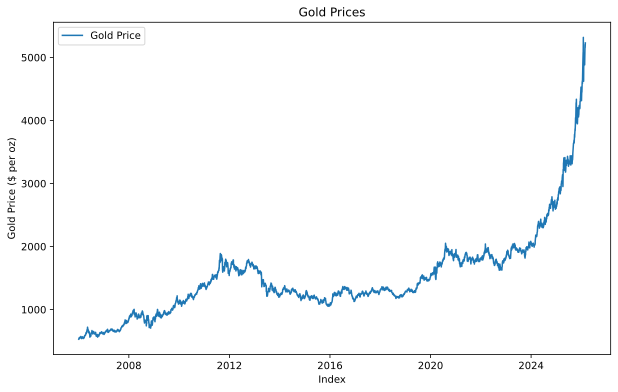

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(df["Gold"], label="Gold Price")
plt.xlabel("Index")  # or use df.index if it has datetime
plt.ylabel("Gold Price ($ per oz)")
plt.title("Gold Prices")
plt.legend()
plt.savefig("results/p1_gold", bbox_inches="tight")
plt.show()

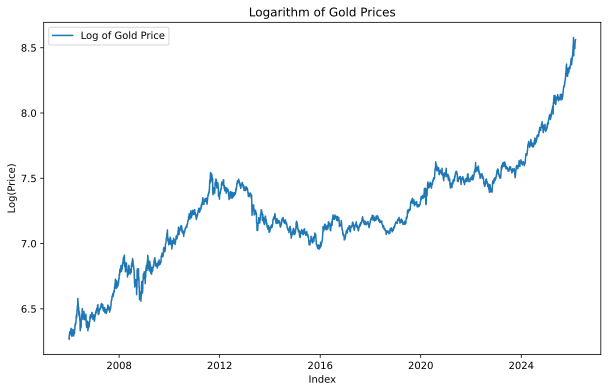

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(df["log_price"], label="Log of Gold Price")
plt.xlabel("Index")  # or use df.index if it has datetime
plt.ylabel("Log(Price)")
plt.title("Logarithm of Gold Prices")
plt.legend()
plt.savefig("results/p1_log_gold", bbox_inches="tight")
plt.show()

## Baseline model to predict next day gold price

## Auto Arima

In [8]:
# Use a large training period, e.g., last 5–10 years
residuals = df["log_price"] - LinearRegression().fit(df[["t"]], df["log_price"]).predict(df[["t"]])

tuned_model = auto_arima(
    residuals,
    stationary=True,
    seasonal=False,
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    max_p=10,
    max_q=10,
    max_d=0,
    trace = True,
    n_jobs=-1
)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=-30245.344, Time=1.04 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=-1023.444, Time=0.34 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=inf, Time=0.38 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=-7566.628, Time=0.60 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-1025.444, Time=0.12 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=-30245.266, Time=0.82 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=-30240.496, Time=2.35 sec
 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=-30243.115, Time=1.76 sec
 ARIMA(2,0,3)(0,0,0)[0] intercept   : AIC=-30242.127, Time=1.20 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-30243.902, Time=0.66 sec
 ARIMA(1,0,3)(0,0,0)[0] intercept   : AIC=-30244.467, Time=0.84 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=-30244.492, Time=0.85 sec
 ARIMA(3,0,3)(0,0,0)[0] intercept   : AIC=-30240.406, Time=4.66 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-30247.240, Time=0.50 sec
 ARIMA(1,0,2)(0

In [9]:
# Save best hyperparameters
p, d, q = tuned_model.order
print("Selected ARIMA order:", (p,d,q))
print("AIC:", tuned_model.aic())

Selected ARIMA order: (2, 0, 2)
AIC: -30247.239679510767


In [10]:
forecast_horizon = 325
start_index = len(df) - forecast_horizon - 1
WINDOW = 252*15

def fit_linear_trend(train_data):
    """Fit a linear trend model to log_price and return model + residuals."""
    X_trend = train_data[["t"]]
    y_trend = train_data["log_price"]

    trend_model = LinearRegression()
    trend_model.fit(X_trend, y_trend)

    train_data = train_data.copy()
    train_data["trend"] = trend_model.predict(X_trend)
    train_data["residual"] = train_data["log_price"] - train_data["trend"]

    return trend_model, train_data


def fit_arma_residual(train_data, p, d, q):
    """Fit an ARIMA model to the residuals and return the fitted model."""
    arma_model = ARIMA(train_data["residual"], order=(p, d, q))
    return arma_model.fit()


def forecast_next_day(trend_model, arma_fitted, last_t):
    """Forecast the next day's gold price using trend + ARMA residual."""
    next_t = np.array([[last_t + 1]])
    trend_forecast = trend_model.predict(next_t)[0]
    residual_forecast = arma_fitted.forecast(steps=1).iloc[0]

    log_price_forecast = trend_forecast + residual_forecast
    return np.exp(log_price_forecast)


def run_rolling_forecast(df, start_index, p, d, q, window=WINDOW):
    """
    Run a rolling window forecast over the dataframe.
    Training data is capped to the last `window` days at each step.

    Returns:
        dates, predictions, actuals — aligned lists for evaluation.
    """
    predictions, actuals, dates = [], [], []
    total = len(df) - start_index - 1

    for i in range(start_index, len(df) - 1):
        percent_complete = (i - start_index + 1) / total * 100
        print(f"\rProgress: {percent_complete:.2f}%", end="")

        train_data = df.iloc[max(0, i - window + 1):i + 1]  # last `window` days only

        trend_model, train_data = fit_linear_trend(train_data)
        arma_fitted = fit_arma_residual(train_data, p, d, q)
        price_forecast = forecast_next_day(trend_model, arma_fitted, train_data["t"].iloc[-1])

        predictions.append(price_forecast)
        actuals.append(df["Gold"].iloc[i + 1])
        dates.append(df.index[i + 1])

    print("\nDone!")
    return dates, predictions, actuals


# --- Usage ---
dates, predictions, actuals = run_rolling_forecast(df, start_index, p, d, q)

Progress: 100.00%
Done!


In [11]:
results = pd.DataFrame({
    "Date": dates,
    "Actual": actuals,
    "Predicted": predictions
}).set_index("Date")

In [12]:
results_2025 = results[results.index.year == 2025]
mape_2025 = (np.abs((results_2025["Actual"] - results_2025["Predicted"]) / results_2025["Actual"]).mean()) * 100
print(f"MAPE 2025: {mape_2025:.2f}%")

MAPE 2025: 0.97%


In [13]:
results_252 = results.iloc[-252:]
mape_252 = (np.abs((results_252["Actual"] - results_252["Predicted"]) / results_252["Actual"]).mean()) * 100
print(f"MAPE (Last 252 Trading Days): {mape_252:.2f}%")

MAPE (Last 252 Trading Days): 1.14%


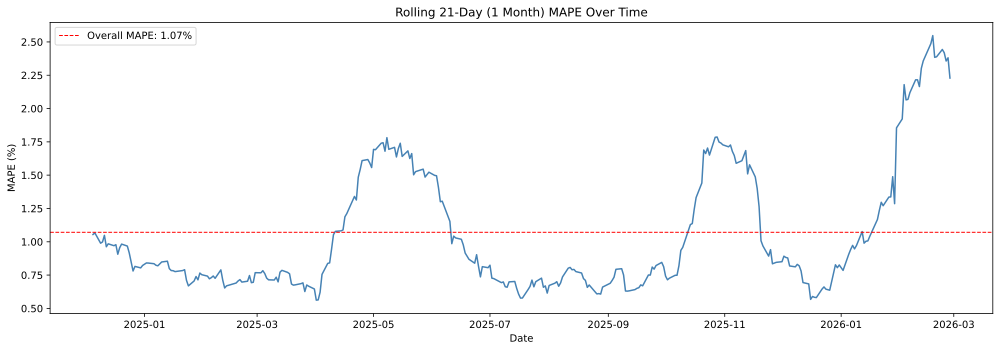

In [14]:
results["APE"] = np.abs((results["Actual"] - results["Predicted"]) / results["Actual"]) * 100
results["Rolling_MAPE"] = results["APE"].rolling(window=21).mean()  # 21 trading days ≈ 1 month

plt.figure(figsize=(14, 5))
plt.plot(results.index, results["Rolling_MAPE"], color="steelblue", linewidth=1.5)
plt.axhline(results["APE"].mean(), color="red", linestyle="--", linewidth=1, label=f'Overall MAPE: {results["APE"].mean():.2f}%')
plt.title("Rolling 21-Day (1 Month) MAPE Over Time")
plt.xlabel("Date")
plt.ylabel("MAPE (%)")
plt.legend()
plt.tight_layout()
plt.savefig("results/p1_rolling_mape", bbox_inches="tight")
plt.show()

In [15]:
def directional_accuracy(df):
    actual_dir = np.sign(df["Actual"].diff())
    predicted_dir = np.sign(df["Predicted"].diff())
    return (actual_dir == predicted_dir).mean() * 100

da_2025 = directional_accuracy(results_2025)
da_252 = directional_accuracy(results_252)

print(f"Directional Accuracy 2025:            {da_2025:.2f}%")
print(f"Directional Accuracy Last 252 Days:   {da_252:.2f}%")

Directional Accuracy 2025:            45.56%
Directional Accuracy Last 252 Days:   45.24%


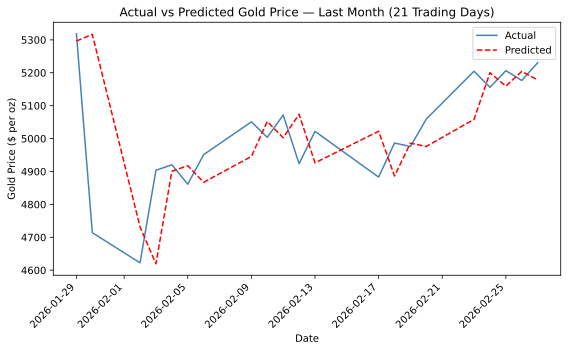

In [20]:
results_last_month = results.iloc[-21:]

plt.figure(figsize=(8, 5))
plt.plot(results_last_month.index, results_last_month["Actual"], color="steelblue", linewidth=1.5, label="Actual")
plt.plot(results_last_month.index, results_last_month["Predicted"], color="red", linewidth=1.5, linestyle="--", label="Predicted")
plt.title("Actual vs Predicted Gold Price — Last Month (21 Trading Days)")
plt.xlabel("Date")
plt.ylabel("Gold Price ($ per oz)")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig("results/p1_last_month_forecast", bbox_inches="tight")
plt.show()